In [13]:
import json
import glob
import math
import os
import random
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm
from ultralytics import YOLO

from datasets import load_dataset
from PIL import Image, ImageDraw, ImageOps
from transformers import AutoImageProcessor, TableTransformerForObjectDetection

try:
    from transformers import DetrImageProcessor as DetrFeatureExtractor
except Exception:
    from transformers import DetrFeatureExtractor
    
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import numpy as np
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



img_root_path = "/home/mohammed/Projects/STP/data/images"
annotations_path = "/home/mohammed/Projects/STP/data/annotations/Cells_Anotations_coco.json"
img_paths = glob.glob(os.path.join(img_root_path, "*.jpg"))


with open(annotations_path, 'r') as f:
    annotations = json.load(f) 


print(type(annotations))   
print(annotations.keys())  

<class 'dict'>
dict_keys(['info', 'images', 'annotations', 'categories'])


In [14]:
!pip install uv
!uv pip install "torch" "torchvision"
!uv pip install "transformers==4.56.1" "datasets" "torchmetrics" "huggingface_hub" "pandas" "tqdm" "pillow" "numpy" "timm" "surya-ocr" "ultralytics"

Using Python 3.10.19 environment at: /home/mohammed/miniconda3/envs/dl_env
Audited 2 packages in 2ms
Using Python 3.10.19 environment at: /home/mohammed/miniconda3/envs/dl_env
Audited 11 packages in 6ms


(764, 1000)


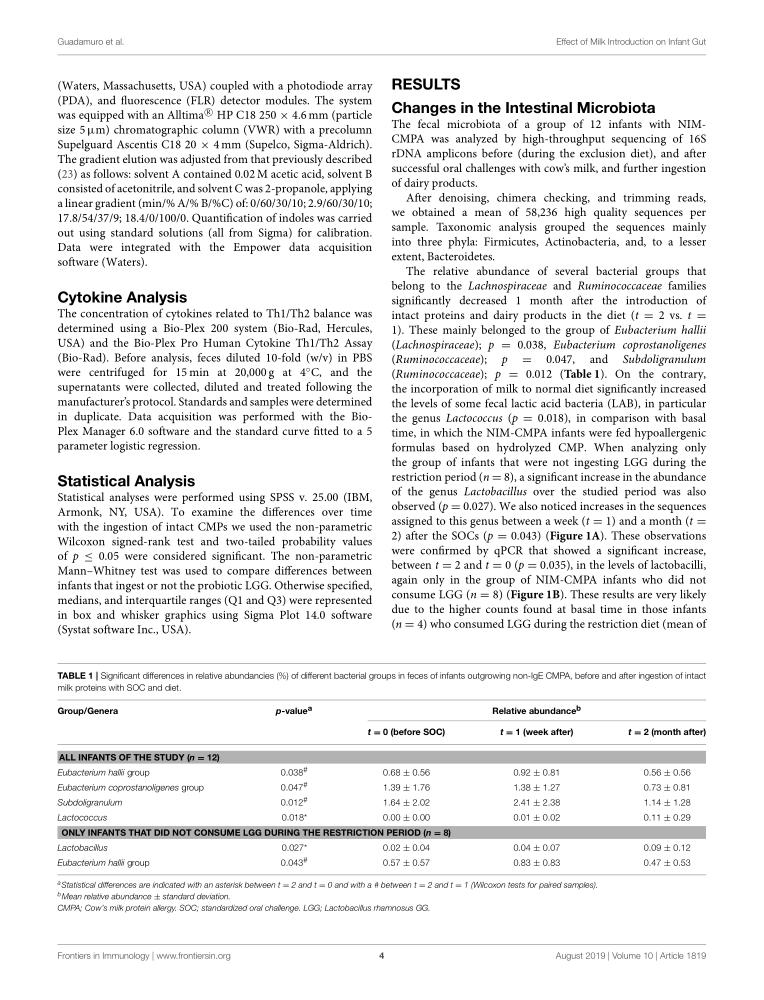

In [15]:
image = Image.open(img_paths[0]).convert("RGB")
print(image.size)
image

In [16]:


def compute_iou(box_a, box_b):
    """IoU between two boxes [x0,y0,x1,y1]."""
    xa = max(box_a[0], box_b[0])
    ya = max(box_a[1], box_b[1])
    xb = min(box_a[2], box_b[2])
    yb = min(box_a[3], box_b[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    area_a = (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])
    area_b = (box_b[2]-box_b[0]) * (box_b[3]-box_b[1])
    union  = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

In [17]:

def get_image_labels(img_paths, labels):
    try:
        file_name = img_paths.split("/")[-1]
        image_id = [d["id"] for d in labels["images"] if d["file_name"] == file_name][0]

        image_labels = [ann for ann in labels["annotations"] if ann["image_id"] == image_id]
    except Exception as e:
        print(f"Error processing {file_name}: {e} where filepath is {img_paths}")
        image_labels = []

    return image_labels

def get_label_category(labels, category_id=1):
    converted = []
    for cat in labels:
        if cat["category_id"] == category_id:
            x, y, w, h = cat["bbox"]  # COCO format
            converted.append([x, y, x + w, y + h])  # PIL format
    return converted

labels = [get_image_labels(img_path, annotations) for img_path in img_paths ]

labels = [get_label_category(label) for label in labels]


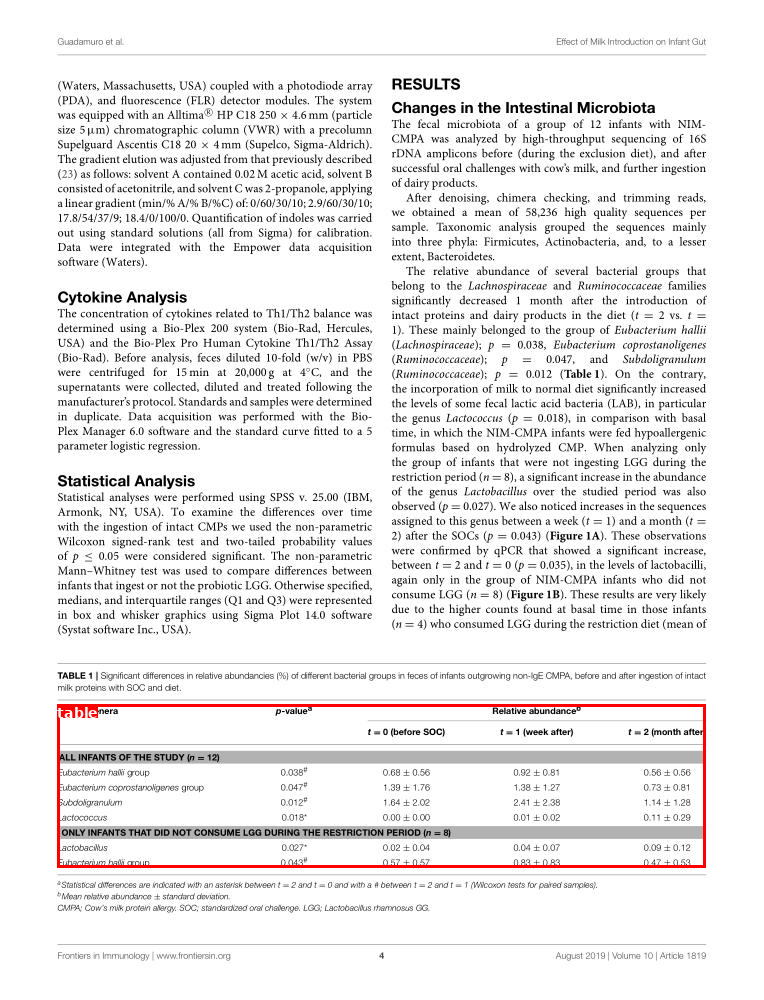

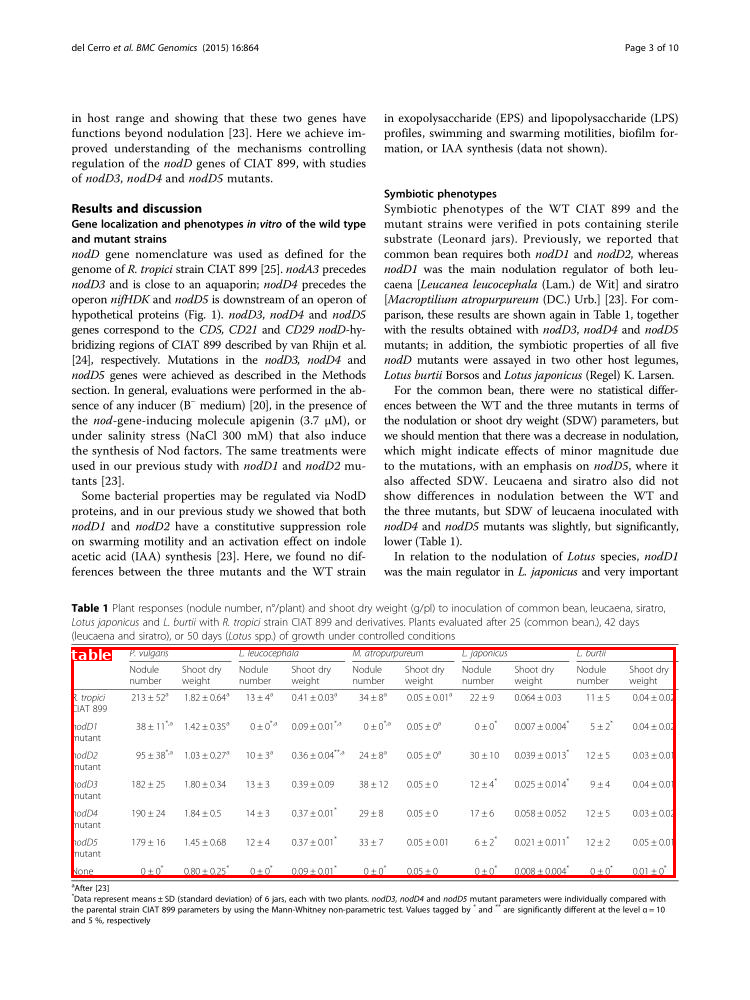

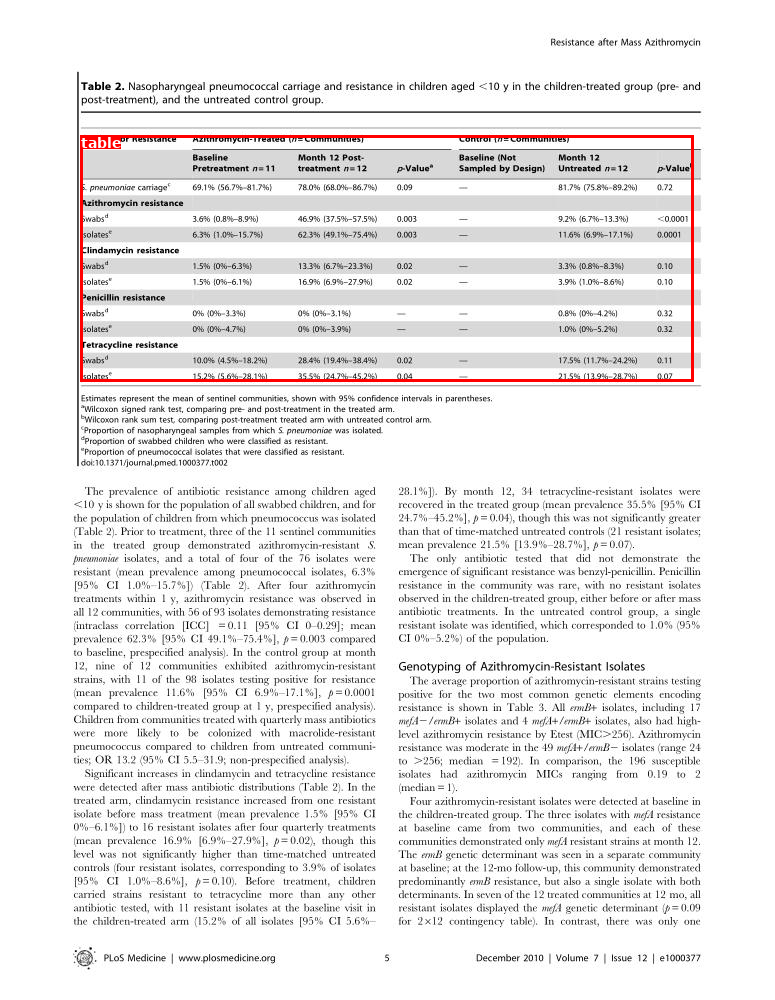

In [18]:
from PIL import Image, ImageDraw, ImageFont
i = 1
for i in range(3):
    for k in range(len(labels[i])):
        box = labels[i][k]
        image = Image.open(img_paths[i]).convert("RGB")
        draw = ImageDraw.Draw(image)

        x0 = min(box[0], box[2])
        y0 = min(box[1], box[3])
        x1 = max(box[0], box[2])
        y1 = max(box[1], box[3])

        # Draw box
        draw.rectangle([x0, y0, x1, y1], outline="red", width=3)

        # Draw label
        label = "table"
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 14)
        except:
            font = ImageFont.load_default()

        text_bbox = draw.textbbox((x0, y0), label, font=font)
        draw.rectangle(text_bbox, fill="red")
        draw.text((x0, y0), label, fill="white", font=font)

        image.save("annotated.png")
        image.show()

In [19]:
class TableStructureDataset(Dataset):
    def __init__(self, image_paths, labels, processor_name, target_size=(750, 1000)):
        self.image_paths = [Path(p) for p in image_paths]
        self.processor   = AutoImageProcessor.from_pretrained(
            processor_name,
            size={"height": target_size[0], "width": target_size[1]},  # (H, W)
        )
        self.target_size = target_size
        self.labels      = labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        orig_w, orig_h = image.size

        encoding = self.processor(images=image, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze(0)  # (3, H, W)

        _, actual_h, actual_w = pixel_values.shape

        scale_x = actual_w / orig_w
        scale_y = actual_h / orig_h

        scaled_boxes = []
        for x0, y0, x1, y1 in self.labels[idx]:
            scaled_boxes.append([
                x0 * scale_x,
                y0 * scale_y,
                x1 * scale_x,
                y1 * scale_y,
            ])

        return {
            "pixel_values": pixel_values,
            "original_size": torch.tensor([actual_h, actual_w]),  # (H, W) 
            "image_path":   str(self.image_paths[idx]),
            "labels":       torch.tensor(scaled_boxes, dtype=torch.float32),  # (N, 4)
        }


def collate_fn(batch):
    return {
        "pixel_values":   torch.stack([b["pixel_values"]  for b in batch]),
        "original_sizes": torch.stack([b["original_size"] for b in batch]),
        "image_paths":    [b["image_path"] for b in batch],
        "labels":         [b["labels"]     for b in batch],  # ← do NOT remove this
    }

train_percentage = 0.74
target_size = (1000 , 750)

train_paths = img_paths[:int(train_percentage*len(img_paths))]
val_paths = img_paths[int(train_percentage*len(img_paths)):]

labels_train = labels[:int(train_percentage*len(labels))]
labels_val = labels[int(train_percentage*len(labels)):]

train_dataset = TableStructureDataset(
    image_paths=train_paths,
    labels=labels_train,
    processor_name="microsoft/table-transformer-structure-recognition",
    target_size = target_size
    )
train_loader = DataLoader(train_dataset,batch_size=2,shuffle = True, collate_fn=
                          collate_fn)


val_dataset = TableStructureDataset(
    image_paths=val_paths,
    labels=labels_val,
    processor_name="microsoft/table-transformer-structure-recognition",
    target_size=target_size
    )
val_loader = DataLoader(val_dataset,batch_size=1,shuffle = False , collate_fn=collate_fn)

print(len(train_dataset), len(val_dataset))

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

1110 390


In [20]:



# Force re-download, ignore cache
processor = AutoImageProcessor.from_pretrained(
    "microsoft/table-transformer-detection",
    force_download=True
)
model = TableTransformerForObjectDetection.from_pretrained(
    "microsoft/table-transformer-detection",
    force_download=True
).to(DEVICE)


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/273 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

/home/mohammed/miniconda3/envs/dl_env/lib/python3.10/site-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/home/mohammed/miniconda3/envs/dl_env/lib/python3.10/site-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/home/mohammed/miniconda3/envs/dl_env/lib/python3.10/site-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a n

In [21]:
map_metric  = MeanAveragePrecision(iou_type="bbox", box_format="xyxy")  
running_iou = []
TABLES_ROOT = Path("tables")
TABLES_ROOT.mkdir(exist_ok=True)

for batch_inputs in tqdm(train_loader, total=len(train_loader)):
    pixel_values   = batch_inputs["pixel_values"].to(DEVICE)
    original_sizes = batch_inputs["original_sizes"]          # (B, 2) — H, W in proc space
    gt_labels      = batch_inputs["labels"]
    image_paths    = batch_inputs["image_paths"]

    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)

    results = processor.post_process_object_detection(
        outputs,
        threshold=0.9,
        target_sizes=original_sizes.to(DEVICE)
    )

    del outputs
    torch.cuda.empty_cache()

    for result, gt_boxes, img_path, orig_size in zip(results, gt_labels, image_paths, original_sizes):
        pred_boxes  = result["boxes"].detach().cpu()
        pred_scores = result["scores"].detach().cpu()
        gt_boxes    = gt_boxes.cpu()

        map_metric.update(
            preds=[{
                "boxes":  pred_boxes,
                "scores": pred_scores,
                "labels": torch.zeros(len(pred_boxes), dtype=torch.long),
            }],
            target=[{
                "boxes":  gt_boxes,
                "labels": torch.zeros(len(gt_boxes), dtype=torch.long),
            }]
        )

        if len(pred_boxes) == 0 or len(gt_boxes) == 0:
            running_iou.append(0.0)
        else:
            ious = [
                max(compute_iou(gt, pred) for pred in pred_boxes.tolist())
                for gt in gt_boxes.tolist()
            ]
            running_iou.append(np.mean(ious))

        img_stem   = Path(img_path).stem
        img_folder = TABLES_ROOT / img_stem
        img_folder.mkdir(exist_ok=True)

        original_image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = original_image.size
        proc_h, proc_w = orig_size.tolist()
        scale_x = orig_w / proc_w
        scale_y = orig_h / proc_h

        crops_meta = []
        for i, (box, score) in enumerate(zip(pred_boxes.tolist(), pred_scores.tolist())):
            px0, py0, px1, py1 = box
            ox0 = max(0,      px0 * scale_x)
            oy0 = max(0,      py0 * scale_y)
            ox1 = min(orig_w, px1 * scale_x)
            oy1 = min(orig_h, py1 * scale_y)
            crop = original_image.crop((ox0, oy0, ox1, oy1))
            crop = ImageOps.expand(crop, border=15, fill="white")
            crop_name = f"table_{i:02d}.png"
            crop.save(img_folder / crop_name)
            crops_meta.append({
                "crop_file":       crop_name,
                "score":           round(score, 4),
                "bbox_proc_space": [round(v, 2) for v in box],
                "bbox_orig_space": [round(ox0,2), round(oy0,2), round(ox1,2), round(oy1,2)],
                "crop_size_wh":    list(crop.size),
            })

        config = {
            "image_path":        img_path,
            "original_size_wh":  [orig_w, orig_h],
            "processed_size_hw": [proc_h, proc_w],
            "scale_back_xy":     [round(scale_x, 6), round(scale_y, 6)],
            "threshold":         0.9,
            "num_detections":    len(pred_boxes),
            "crops":             crops_meta,
            "gt_boxes":          [[round(v, 2) for v in b] for b in gt_boxes.tolist()],
        }
        with open(img_folder / "config.json", "w") as f:
            json.dump(config, f, indent=2)

    print(f"  running mIoU: {np.mean(running_iou):.4f}", end="\r")

final_map = map_metric.compute()
print("\n── Final Metrics ──")
print(f"  mAP@0.5:0.95 : {final_map['map'].item():.4f}")
print(f"  mAP@0.5      : {final_map['map_50'].item():.4f}")
print(f"  mAP@0.75     : {final_map['map_75'].item():.4f}")
print(f"  mean IoU     : {np.mean(running_iou):.4f}")

  0%|          | 0/555 [00:00<?, ?it/s]

  running mIoU: 0.9804
── Final Metrics ──
  mAP@0.5:0.95 : 0.9792
  mAP@0.5      : 0.9901
  mAP@0.75     : 0.9901
  mean IoU     : 0.9804
